In [22]:
# ── Settings ─────────────────────────────────────────────────────────────
n_steps   = 250        # sloppy steps per run
step_size = 0.1         # step size in log-parameter space
tol_positive_eig = -5 # eigenvalue threshold for "positive"
sloppy_threshold = 1e-3

RANDOM_STARTING_POINT = False  # randomise starting parameters each run
MULT  = True   # if True, sample from all sloppy eigenvectors (log-weighted)
NOISE = 0   # Gaussian noise variance added to each step vector


In [23]:
# ── Imports & model setup ─────────────────────────────────────────────────
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.integrate import solve_ivp
from numpy.linalg import eigh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Canonical parameter set
p_canonical = {
    "k1_aa_over_CT": 0.015,
    "k2":            0.0,
    "k3_CT":         200.0,
    "k4":            180.0,
    "k4prime":       0.018,
    "k5_minusP":     0.0,
    "k6":            1.0,
    "k7":            0.6,
    "k8_minusP":     100.0,
    "k9":            50.0,
    "CT":            1.0,
}

param_names = ["k1_aa_over_CT", "k3_CT", "k4", "k4prime", "k6", "k7"]
P  = len(param_names)
CT = p_canonical["CT"]

# Initial state and time grid
y0     = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
t_span = (0.0, 100.0)
t_eval = np.linspace(0.0, 100.0, 1001)

# ── Model functions ───────────────────────────────────────────────────────
def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p["CT"]
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def jacobian_fx(x, p):
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    dF = dF_dM(M, p)
    J = np.zeros((6, 6))
    J[0, 0] = -p["k8_minusP"]; J[0, 1] = p["k9"];           J[0, 3] = p["k6"]
    J[1, 0] =  p["k8_minusP"]; J[1, 1] = -k3*Y - p["k9"];   J[1, 4] = -k3*CP
    J[2, 1] =  k3*Y;           J[2, 2] = -F_M(M, p)
    J[2, 3] = -pM * dF + p["k5_minusP"]; J[2, 4] = k3*CP
    J[3, 2] =  F_M(M, p);     J[3, 3] = pM * dF - p["k5_minusP"] - p["k6"]
    J[4, 1] = -k3 * Y;        J[4, 4] = -p["k2"] - k3 * CP
    J[5, 3] =  p["k6"];       J[5, 5] = -p["k7"]
    return J

def df_dparam(x, p):
    C2, CP, pM, M, Y, YP = x
    dfdh = np.zeros((6, P))
    for j, name in enumerate(param_names):
        df = np.zeros(6)
        if name == "k1_aa_over_CT":
            df[4] = p["CT"]
        elif name == "k3_CT":
            c = 1.0 / p["CT"]
            df[1] = -c*CP*Y; df[2] = c*CP*Y; df[4] = -c*CP*Y
        elif name == "k4":
            d = (M / p["CT"])**2
            df[2] = -pM*d; df[3] = pM*d
        elif name == "k4prime":
            df[2] = -pM; df[3] = pM
        elif name == "k6":
            df[0] = M; df[3] = -M; df[5] = M
        elif name == "k7":
            df[5] = -YP
        elif name == "k8_minusP":
            df[0] = -C2; df[1] = C2
        elif name == "k9":
            df[0] = CP; df[1] = -CP
        else:
            raise KeyError(name)
        dfdh[:, j] = df
    return dfdh

# ── Simulation helpers ────────────────────────────────────────────────────
def simulate_at_params(p_local, t_eval_in):
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local),
                    (t_eval_in[0], t_eval_in[-1]), y0,
                    method='BDF', t_eval=t_eval_in, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integration failed: " + sol.message)
    return sol.t, sol.y

def compute_obs(X):
    C2, CP, pM, M, Y, YP = X
    YT = Y + YP + pM + M
    return YT / CT, M / CT

def compute_H_for_params(p_local):
    def aug_rhs(t, z):
        x    = z[:6]
        S    = z[6:].reshape((6, P), order='F')
        xdot = f_rhs(t, x, p_local)
        A    = jacobian_fx(x, p_local)
        dfdh = df_dparam(x, p_local)
        dfdlogh = np.zeros_like(dfdh)
        for j, name in enumerate(param_names):
            dfdlogh[:, j] = p_local[name] * dfdh[:, j]
        Sdot = A.dot(S) + dfdlogh
        return np.concatenate([xdot, Sdot.ravel(order='F')])

    z0  = np.concatenate([y0, np.zeros((6, P)).ravel(order='F')])
    sol = solve_ivp(aug_rhs, t_span, z0, method='BDF',
                    t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Augmented integration failed: " + sol.message)

    m       = sol.t.size
    S_flat  = sol.y[6:, :]
    S_time  = np.zeros((6, P, m))
    for i in range(m):
        S_time[:, :, i] = S_flat[:, i].reshape((6, P), order='F')

    W  = np.diag(np.ones(6) / (6 * (t_span[1] - t_span[0])))
    tt = sol.t
    dt = np.diff(tt)
    q  = np.zeros_like(tt)
    q[0] = dt[0]/2; q[-1] = dt[-1]/2
    q[1:-1] = 0.5*(dt[:-1] + dt[1:])

    H = np.zeros((P, P))
    for i in range(m):
        Ji = S_time[:, :, i]
        H += q[i] * Ji.T.dot(W).dot(Ji)

    ev, evec = eigh(H)
    ev = ev[::-1]; evec = evec[:, ::-1]
    return dict(H=H, eigvals=ev, eigvecs=evec, t=sol.t, q=q)

print("Model and helpers ready.")


Model and helpers ready.


Run 1/6 ... 

done  (250 steps)
Run 2/6 ... done  (250 steps)
Run 3/6 ... done  (250 steps)
Run 4/6 ... done  (250 steps)
Run 5/6 ... done  (250 steps)
Run 6/6 ... done  (250 steps)


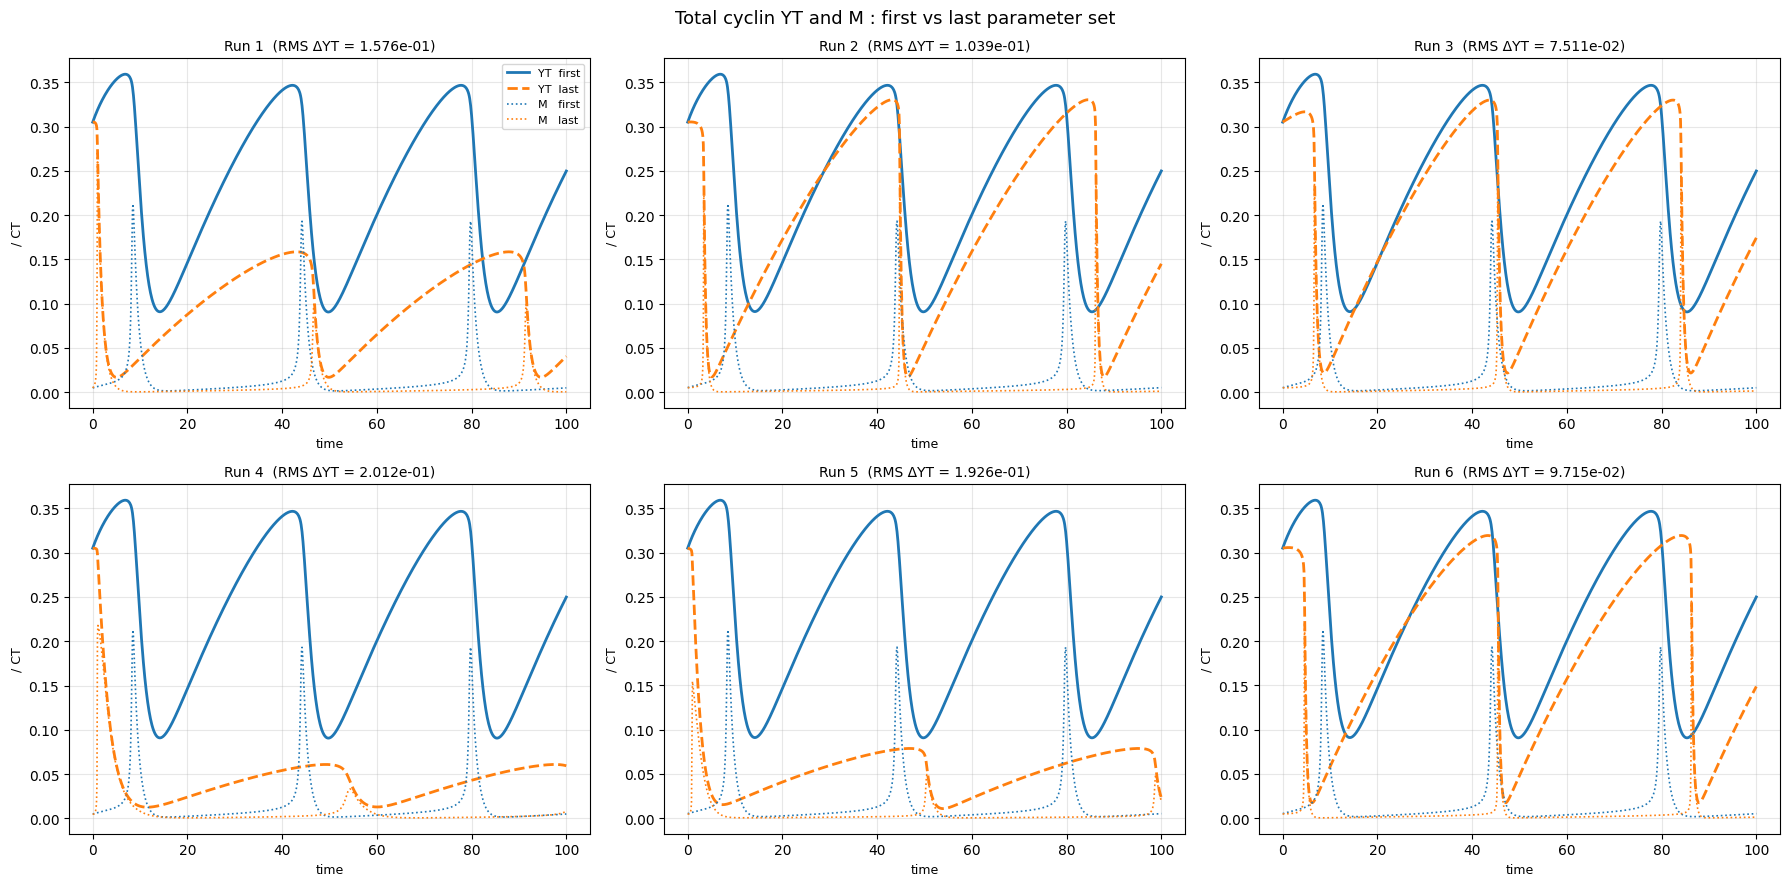

/tmp/ipykernel_1023172/1099960804.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = cm.get_cmap('viridis', max(n_s, 2))
/tmp/ipykernel_1023172/1099960804.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = cm.get_cmap('viridis', max(n_s, 2))
/tmp/ipykernel_1023172/1099960804.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = cm.get_cmap('viridis', max(n_s, 2))
/tmp/ipykernel_1023172/1099960804.py:123: MatplotlibDeprecationWarn

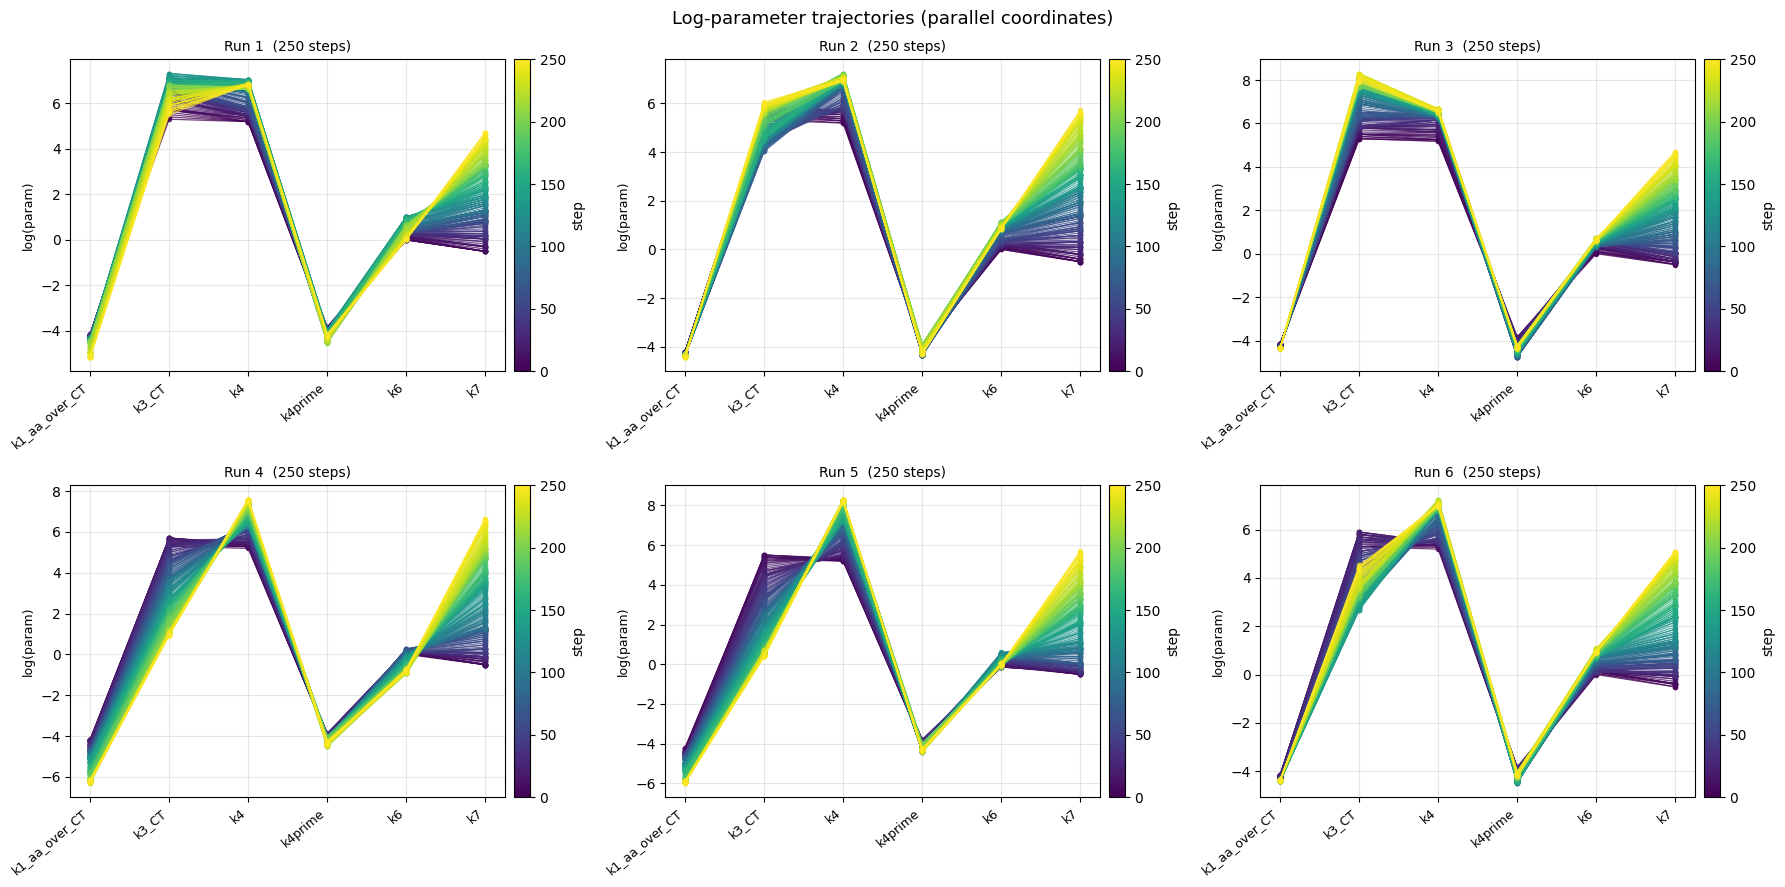

/tmp/ipykernel_1023172/1099960804.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r   = cm.get_cmap('viridis', max(n_s, 2))


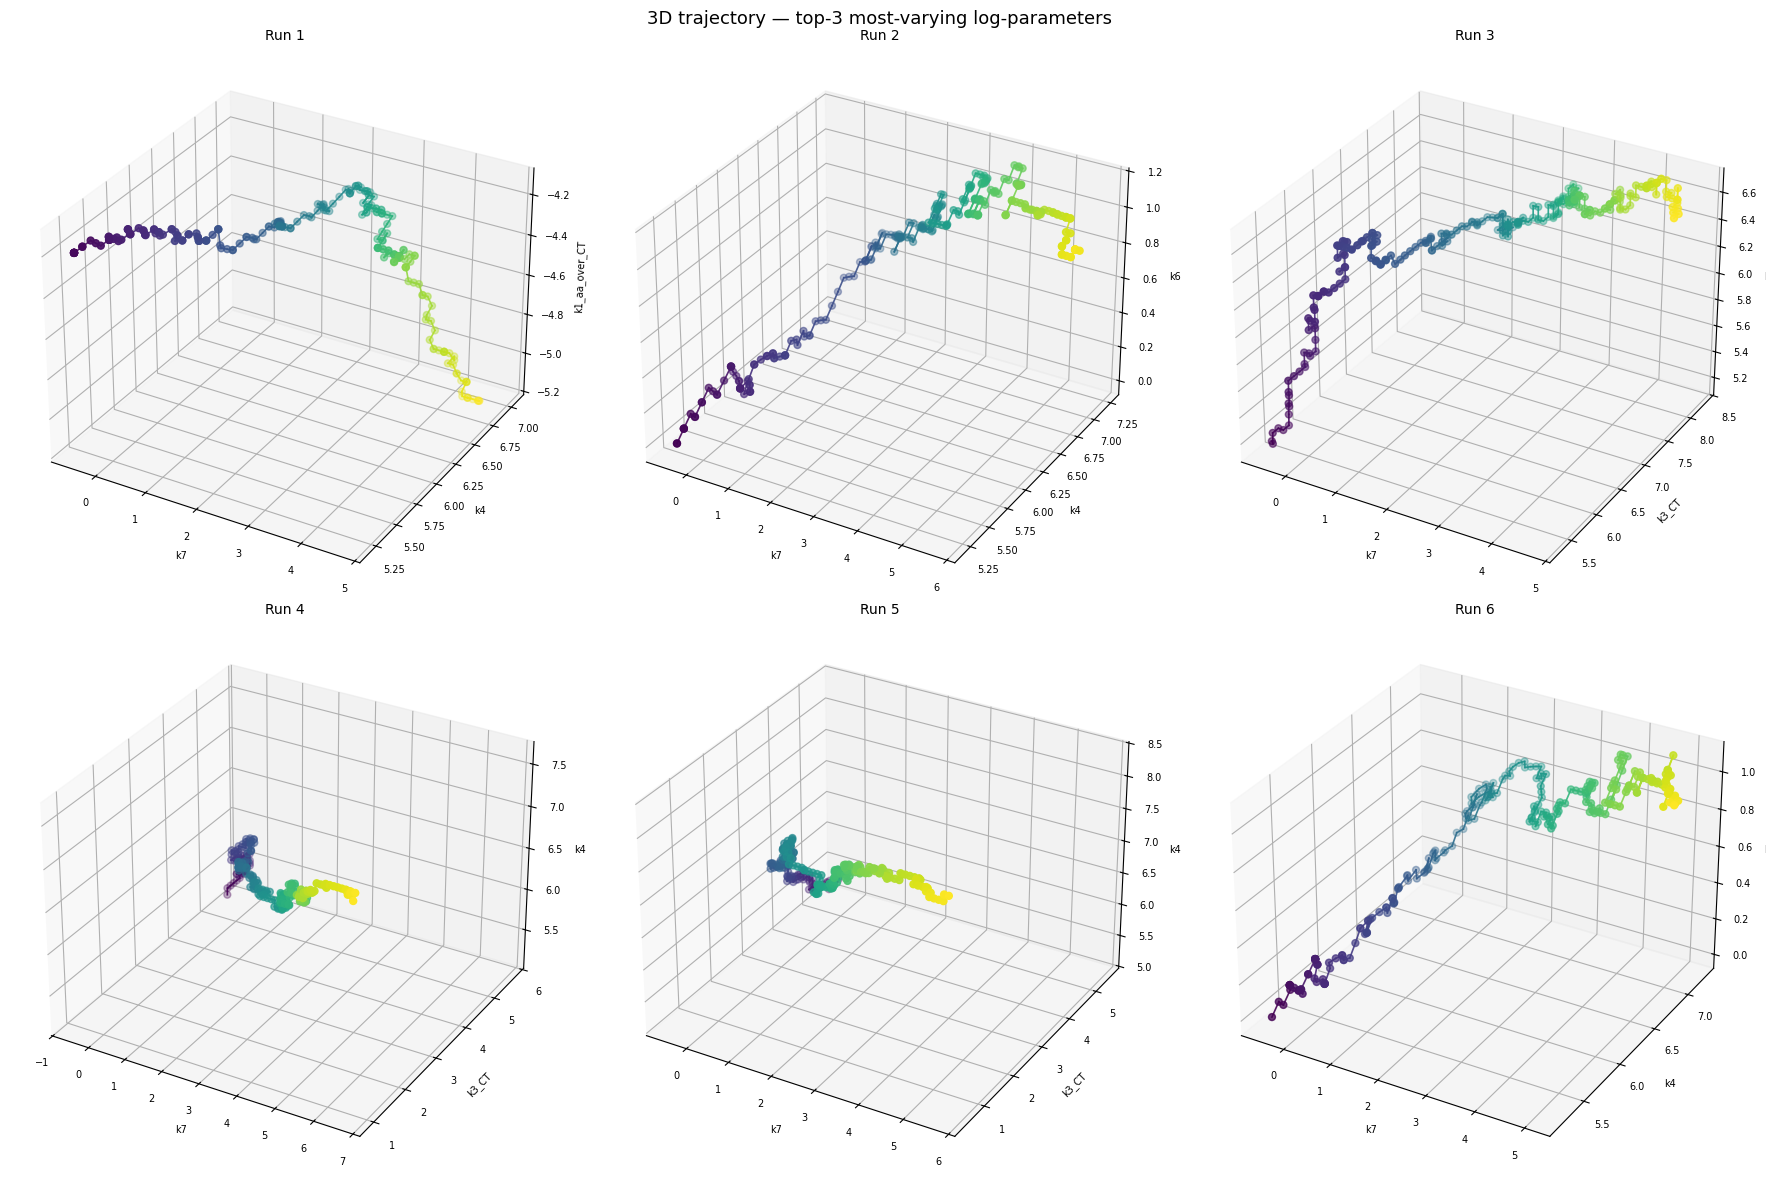

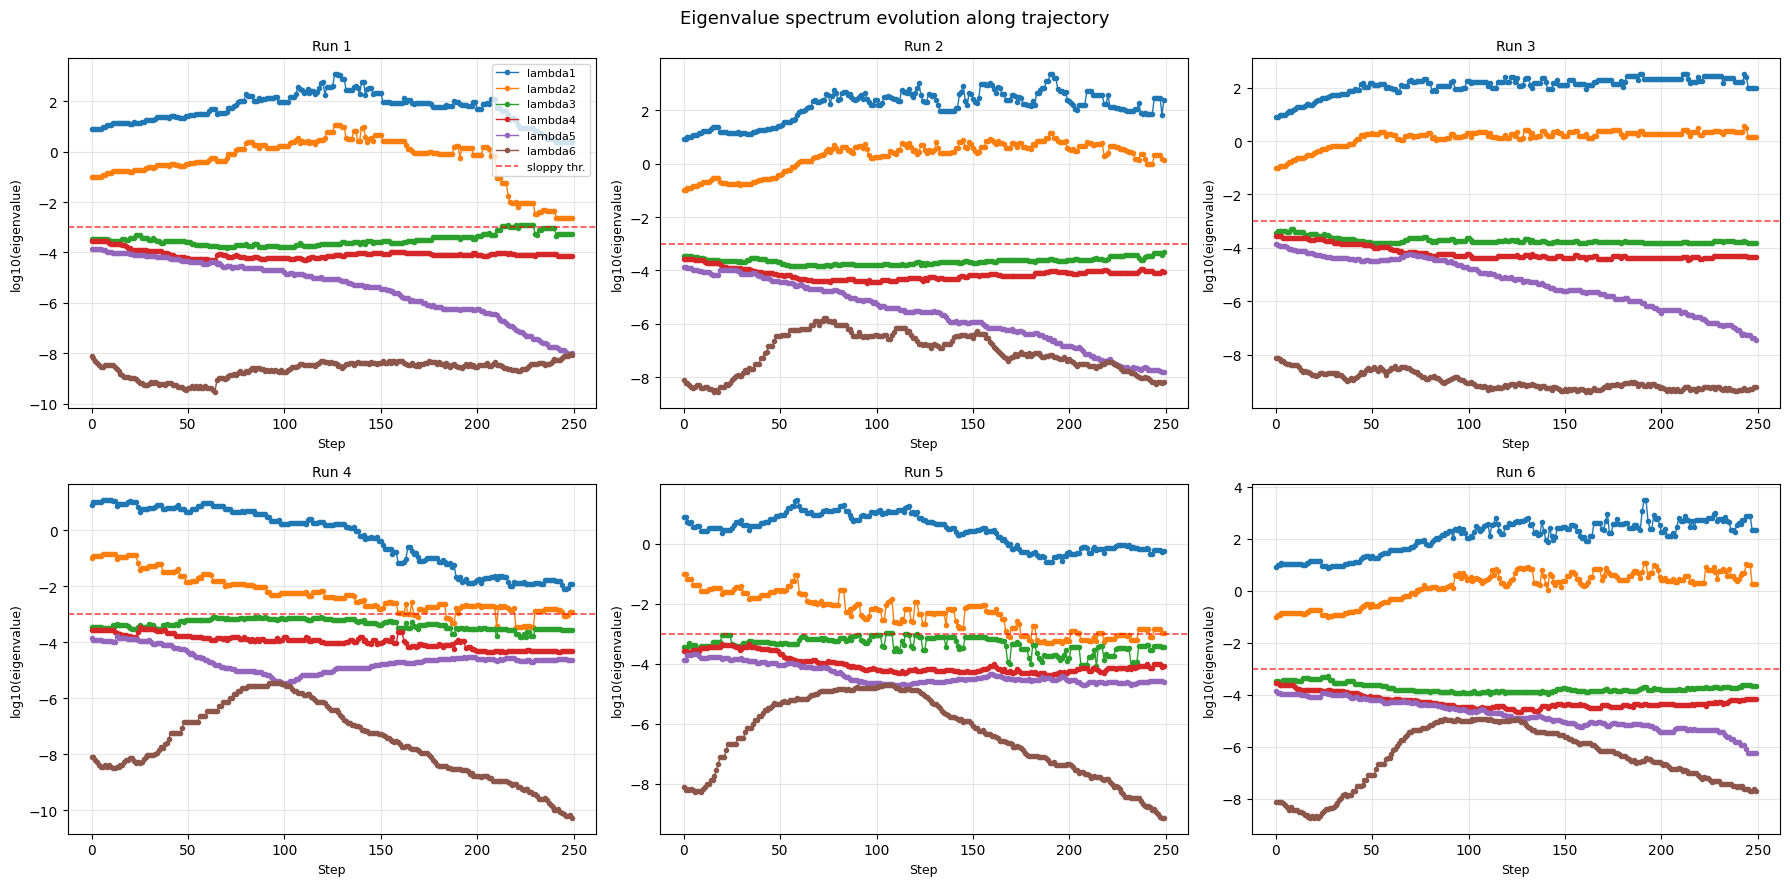

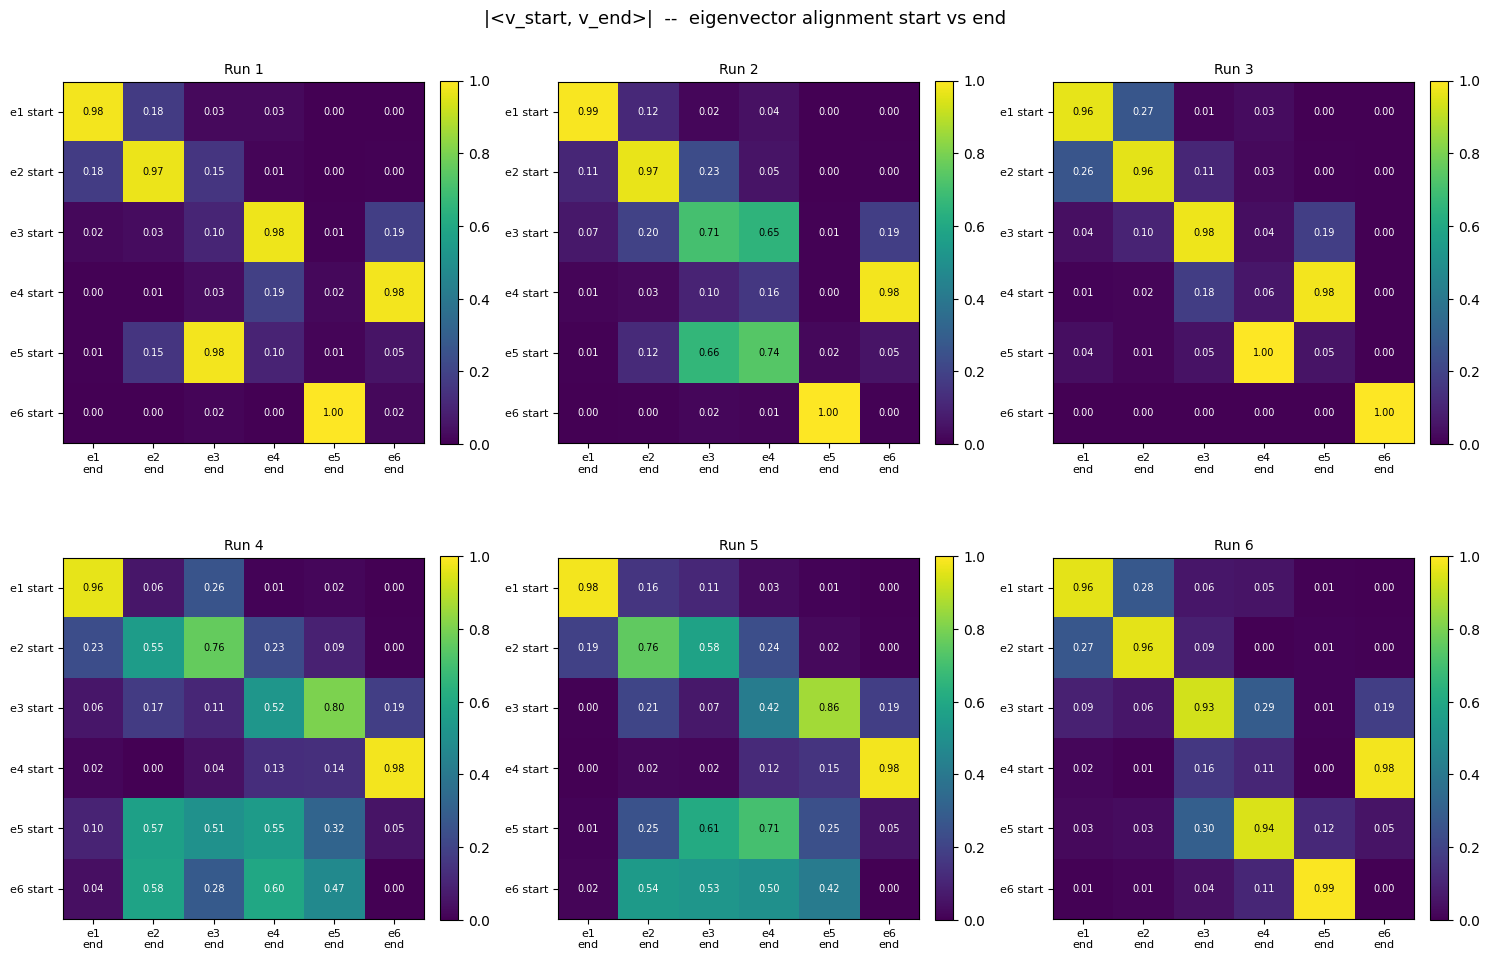

In [24]:
# ── Multi-run sloppy stepping ─────────────────────────────────────────────
N_RUNS = 6

def _random_start(p_template):
    multipliers = [1/8, 1/4, 1/2, 1, 2, 4, 8]
    out = dict(p_template)
    for name in out:
        if name != "CT":
            out[name] *= np.random.choice(multipliers)
    return out

def run_sloppy_steps(p_start):
    t_eval_run    = t_eval
    p_cur         = dict(p_start)
    param_hist    = [copy.deepcopy(p_cur)]
    logparam_hist = [np.log([p_cur[name] for name in param_names])]
    obs_hist, score_hist, eig_hist, vec_hist = [], [], [], []

    _, X0b = simulate_at_params(p_cur, t_eval_run)
    YT0b, M0b = compute_obs(X0b)
    obs_hist.append((YT0b.copy(), M0b.copy()))

    for step in range(1, n_steps + 1):
        res = compute_H_for_params(p_cur)
        ev, evec = res['eigvals'], res['eigvecs']
        eig_hist.append(ev.copy())
        vec_hist.append(evec.copy())

        pos_idx = np.where(ev > tol_positive_eig)[0]
        if pos_idx.size == 0:
            break

        if MULT:
            eps    = 1e-30
            clipped = np.maximum(ev[pos_idx], eps)
            lw     = np.maximum(-np.log10(clipped), 0)
            tot    = lw.sum()
            probs  = lw / tot if tot > 0 else np.ones(len(pos_idx)) / len(pos_idx)
            probs /= probs.sum()
            sloppy_idx = np.random.choice(pos_idx, p=probs)
        else:
            sloppy_idx = pos_idx[-1]

        v     = evec[:, sloppy_idx]
        dlogh = step_size * v
        if NOISE > 0:
            dlogh = dlogh + np.random.normal(0, np.sqrt(NOISE), size=P)

        p_plus  = {name: p_cur[name] * np.exp(+dlogh[j]) for j, name in enumerate(param_names)}
        p_minus = {name: p_cur[name] * np.exp(-dlogh[j]) for j, name in enumerate(param_names)}
        for k in p_cur:
            if k not in param_names:
                p_plus[k] = p_cur[k]; p_minus[k] = p_cur[k]

        tt   = t_eval_run
        dt_r = np.diff(tt)
        q_r  = np.zeros_like(tt)
        q_r[0] = dt_r[0]/2; q_r[-1] = dt_r[-1]/2
        q_r[1:-1] = 0.5*(dt_r[:-1] + dt_r[1:])

        _, Xc = simulate_at_params(p_cur,   tt); YTc, Mc = compute_obs(Xc)
        _, Xp = simulate_at_params(p_plus,  tt); YTp, Mp = compute_obs(Xp)
        _, Xm = simulate_at_params(p_minus, tt); YTm, Mm = compute_obs(Xm)

        def isq(A, B): return np.sum(q_r * (A-B)**2)
        if isq(YTc,YTp)+isq(Mc,Mp) <= isq(YTc,YTm)+isq(Mc,Mm):
            p_next, YT_n, M_n, sc = p_plus,  YTp, Mp, isq(YTc,YTp)+isq(Mc,Mp)
        else:
            p_next, YT_n, M_n, sc = p_minus, YTm, Mm, isq(YTc,YTm)+isq(Mc,Mm)

        param_hist.append(copy.deepcopy(p_next))
        logparam_hist.append(np.log([p_next[name] for name in param_names]))
        obs_hist.append((YT_n.copy(), M_n.copy()))
        score_hist.append(sc)
        p_cur = p_next

    return np.vstack(logparam_hist), param_hist, obs_hist, score_hist, eig_hist, vec_hist


# ── Run N_RUNS times ──────────────────────────────────────────────────────
all_lpm, all_param_hists, all_eig_hists, all_vec_hists = [], [], [], []
for run in range(N_RUNS):
    print(f"Run {run+1}/{N_RUNS} ...", end=' ', flush=True)
    p_run = _random_start(p_canonical) if RANDOM_STARTING_POINT else dict(p_canonical)
    lpm, ph, oh, sh, eh, vh = run_sloppy_steps(p_run)
    all_lpm.append(lpm); all_param_hists.append(ph)
    all_eig_hists.append(eh); all_vec_hists.append(vh)
    print(f"done  ({lpm.shape[0]-1} steps)")

xs_pc = np.arange(len(param_names))


# ── Figure 1: Total cyclin (YT) and M  —  first vs last  2x3 ─────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 9))
for run, ax in enumerate(axes1.flatten()):
    p_first = all_param_hists[run][0]
    p_last  = all_param_hists[run][-1]
    _, Xf = simulate_at_params(p_first, t_eval)
    _, Xl = simulate_at_params(p_last,  t_eval)
    YTf, Mf = compute_obs(Xf)
    YTl, Ml = compute_obs(Xl)
    dist = np.sqrt(np.mean((YTf - YTl)**2))
    ax.plot(t_eval, YTf, color='C0', lw=2.0,            label='YT  first')
    ax.plot(t_eval, YTl, color='C1', lw=2.0, ls='--',   label='YT  last')
    ax.plot(t_eval, Mf,  color='C0', lw=1.2, ls=':',    label='M   first')
    ax.plot(t_eval, Ml,  color='C1', lw=1.2, ls=':',    label='M   last')
    ax.set_xlabel('time', fontsize=9)
    ax.set_ylabel('/ CT', fontsize=9)
    ax.set_title(f'Run {run+1}  (RMS ΔYT = {dist:.3e})', fontsize=10)
    ax.grid(True, alpha=0.3)
    if run == 0:
        ax.legend(fontsize=8)
fig1.suptitle('Total cyclin YT and M : first vs last parameter set', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 2: Log-parameter trajectories (parallel coordinates)  2×3 ─────
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))
for run, ax in enumerate(axes2.flatten()):
    lpm = all_lpm[run]
    n_s = lpm.shape[0]
    cmap_r = cm.get_cmap('viridis', max(n_s, 2))
    norm_r = mcolors.Normalize(vmin=0, vmax=max(n_s-1, 1))
    for i in range(n_s):
        ax.plot(xs_pc, lpm[i, :], '-o', color=cmap_r(norm_r(i)),
                alpha=0.75, markersize=3, linewidth=0.9)
    ax.set_xticks(xs_pc)
    ax.set_xticklabels(param_names, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('log(param)', fontsize=9)
    ax.set_title(f'Run {run+1}  ({n_s-1} steps)', fontsize=10)
    ax.grid(True, alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=norm_r)
    sm.set_array([])
    fig2.colorbar(sm, ax=ax, fraction=0.04, pad=0.02, label='step')
fig2.suptitle('Log-parameter trajectories (parallel coordinates)', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 3: 3D trajectory of top-3 most-varying log-params  2×3 ─────────
fig3 = plt.figure(figsize=(18, 12))
for run in range(N_RUNS):
    lpm      = all_lpm[run]
    log_diff = np.abs(lpm[-1] - lpm[0])
    top3     = np.argsort(log_diff)[-3:][::-1]
    coords   = lpm[:, top3]
    n_s      = lpm.shape[0]
    cmap_r   = cm.get_cmap('viridis', max(n_s, 2))
    norm_r   = mcolors.Normalize(vmin=0, vmax=max(n_s-1, 1))

    ax = fig3.add_subplot(2, 3, run+1, projection='3d')
    for i in range(n_s - 1):
        ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2],
                '-', color=cmap_r(norm_r(i)), alpha=0.9, linewidth=1.2)
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
               c=np.arange(n_s), cmap=cmap_r, norm=norm_r, s=25)
    ax.set_xlabel(param_names[top3[0]], fontsize=7, labelpad=2)
    ax.set_ylabel(param_names[top3[1]], fontsize=7, labelpad=2)
    ax.set_zlabel(param_names[top3[2]], fontsize=7, labelpad=2)
    ax.set_title(f'Run {run+1}', fontsize=10)
    ax.tick_params(labelsize=7)
fig3.suptitle('3D trajectory — top-3 most-varying log-parameters', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 4: Eigenvalue spectrum evolution over trajectory  2×3 ──────────
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 9))
for run, ax in enumerate(axes4.flatten()):
    eh = all_eig_hists[run]
    if len(eh) == 0:
        ax.set_title(f'Run {run+1}: no data'); continue
    eig_mat = np.array(eh)
    for j in range(P):
        log_ev = np.log10(np.maximum(eig_mat[:, j], 1e-30))
        ax.plot(np.arange(len(eh)), log_ev, '-o',
                label=f'lambda{j+1}', markersize=3, linewidth=1.0)
    ax.axhline(np.log10(sloppy_threshold), color='red', linestyle='--',
               linewidth=1.2, alpha=0.7, label='sloppy thr.')
    ax.set_xlabel('Step', fontsize=9)
    ax.set_ylabel('log10(eigenvalue)', fontsize=9)
    ax.set_title(f'Run {run+1}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if run == 0:
        ax.legend(fontsize=8, loc='upper right')
fig4.suptitle('Eigenvalue spectrum evolution along trajectory', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 5: Eigenvector inner-product matrices (start vs end)  2×3 ──────
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 10))
for run, ax in enumerate(axes5.flatten()):
    vh = all_vec_hists[run]
    if len(vh) < 2:
        ax.set_title(f'Run {run+1}: too few steps'); continue
    V_start = vh[0]
    V_end   = vh[-1]
    IP = np.abs(V_start.T @ V_end)
    im = ax.imshow(IP, vmin=0, vmax=1, cmap='viridis', aspect='equal')
    ax.set_xticks(range(P)); ax.set_yticks(range(P))
    ax.set_xticklabels([f'e{i+1}\nend'   for i in range(P)], fontsize=8)
    ax.set_yticklabels([f'e{i+1} start' for i in range(P)], fontsize=8)
    for i in range(P):
        for j in range(P):
            ax.text(j, i, f'{IP[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if IP[i,j] < 0.6 else 'black')
    ax.set_title(f'Run {run+1}', fontsize=10)
    fig5.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig5.suptitle('|<v_start, v_end>|  --  eigenvector alignment start vs end', fontsize=13)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1023172/2492646325.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  run_cmap = cm.get_cmap('tab10', max(N_RUNS, 3))


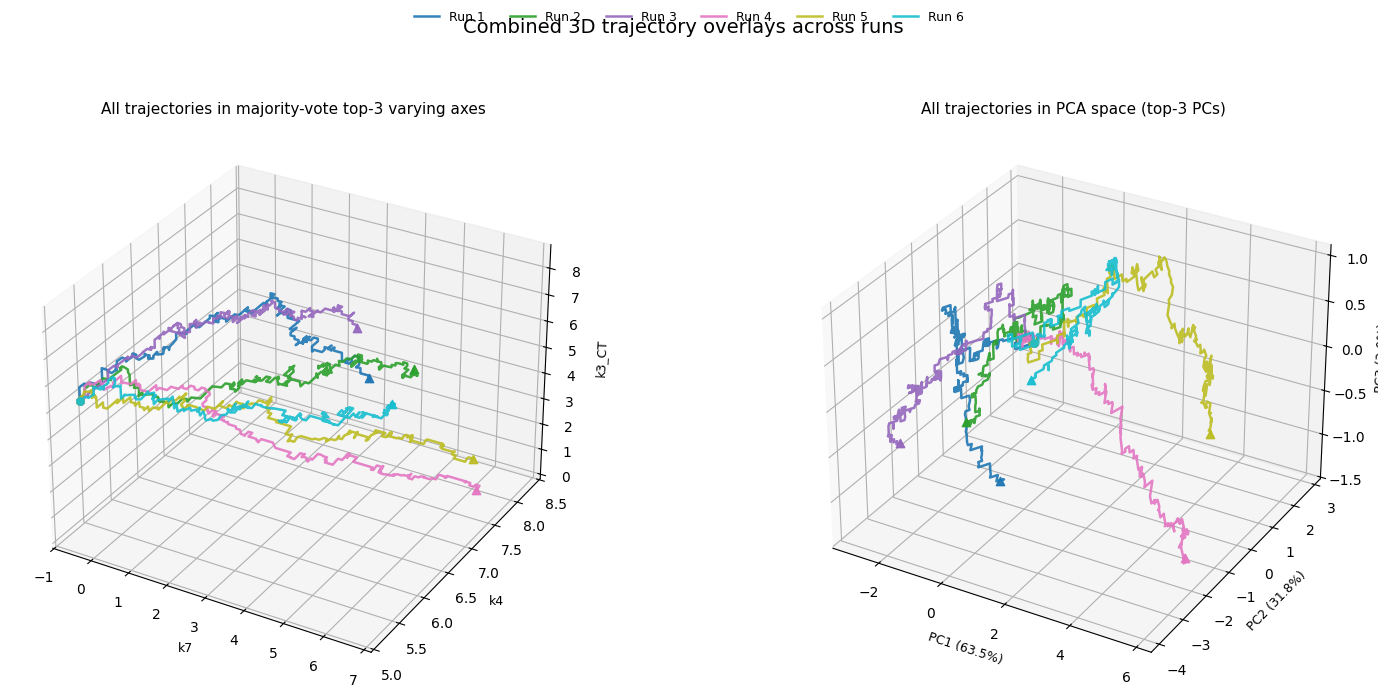

Majority-vote top-3 varying parameter axes: k7, k4, k3_CT
Vote counts per parameter:
  k1_aa_over_CT: 1
  k3_CT: 3
  k4: 6
  k4prime: 0
  k6: 2
  k7: 6
PCA explained variance (PC1-3): 63.5%, 31.8%, 3.0%


In [ ]:
# ── Figure 6a/6b: Combined 3D overlays as TWO separate interactive plots ──
# This creates two independent 3D figures so each can be rotated with the cursor.

if len(all_lpm) == 0:
    raise RuntimeError("No trajectories found in all_lpm. Run the multi-run cell first.")

# Majority vote for the 3 most-varying parameter axes across runs
vote_counts = np.zeros(P, dtype=int)
for lpm in all_lpm:
    per_run_top3 = np.argsort(np.abs(lpm[-1] - lpm[0]))[-3:]
    vote_counts[per_run_top3] += 1

majority_top3 = np.argsort(vote_counts)[-3:][::-1]
majority_labels = [param_names[i] for i in majority_top3]

# PCA over all trajectory points from all runs
X_all = np.vstack(all_lpm)
X_mean = X_all.mean(axis=0, keepdims=True)
X_centered = X_all - X_mean

_, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
pc_axes = Vt[:3].T  # shape: (P, 3)
var_explained = (singular_values**2) / np.sum(singular_values**2)

run_cmap = cm.get_cmap('tab10', max(N_RUNS, 3))

# ── Figure 6a: Majority-vote axes overlay ─────────────────────────────────────
fig_majority = plt.figure(figsize=(9, 7))
ax_majority = fig_majority.add_subplot(1, 1, 1, projection='3d')

for run, lpm in enumerate(all_lpm):
    run_color = run_cmap(run % run_cmap.N)
    coords_major = lpm[:, majority_top3]

    ax_majority.plot(coords_major[:, 0], coords_major[:, 1], coords_major[:, 2],
                     '-', color=run_color, linewidth=1.8, alpha=0.9, label=f'Run {run+1}')
    ax_majority.scatter(coords_major[0, 0], coords_major[0, 1], coords_major[0, 2],
                        color=run_color, marker='o', s=28, alpha=0.9)
    ax_majority.scatter(coords_major[-1, 0], coords_major[-1, 1], coords_major[-1, 2],
                        color=run_color, marker='^', s=36, alpha=0.95)

ax_majority.set_xlabel(majority_labels[0], fontsize=10, labelpad=6)
ax_majority.set_ylabel(majority_labels[1], fontsize=10, labelpad=6)
ax_majority.set_zlabel(majority_labels[2], fontsize=10, labelpad=6)
ax_majority.set_title('All trajectories in majority-vote top-3 varying axes', fontsize=12)
ax_majority.grid(True, alpha=0.3)
ax_majority.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

# ── Figure 6b: PCA axes overlay ───────────────────────────────────────────────
fig_pca = plt.figure(figsize=(9, 7))
ax_pca = fig_pca.add_subplot(1, 1, 1, projection='3d')

for run, lpm in enumerate(all_lpm):
    run_color = run_cmap(run % run_cmap.N)
    coords_pca = (lpm - X_mean) @ pc_axes

    ax_pca.plot(coords_pca[:, 0], coords_pca[:, 1], coords_pca[:, 2],
                '-', color=run_color, linewidth=1.8, alpha=0.9, label=f'Run {run+1}')
    ax_pca.scatter(coords_pca[0, 0], coords_pca[0, 1], coords_pca[0, 2],
                   color=run_color, marker='o', s=28, alpha=0.9)
    ax_pca.scatter(coords_pca[-1, 0], coords_pca[-1, 1], coords_pca[-1, 2],
                   color=run_color, marker='^', s=36, alpha=0.95)

ax_pca.set_xlabel(f'PC1 ({100*var_explained[0]:.1f}%)', fontsize=10, labelpad=6)
ax_pca.set_ylabel(f'PC2 ({100*var_explained[1]:.1f}%)', fontsize=10, labelpad=6)
ax_pca.set_zlabel(f'PC3 ({100*var_explained[2]:.1f}%)', fontsize=10, labelpad=6)
ax_pca.set_title('All trajectories in PCA space (top-3 PCs)', fontsize=12)
ax_pca.grid(True, alpha=0.3)
ax_pca.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

print('Majority-vote top-3 varying parameter axes:', ', '.join(majority_labels))
print('Vote counts per parameter:')
for i, name in enumerate(param_names):
    print(f'  {name}: {vote_counts[i]}')
print(f'PCA explained variance (PC1-3): {100*var_explained[0]:.1f}%, {100*var_explained[1]:.1f}%, {100*var_explained[2]:.1f}%')